# Weekly Dengue Forecasting in Sri Lanka Using Machine Learning and Time-Series Models

## Capstone Project II – DS4105

### Project Overview
This project develops and evaluates forecasting models for predicting weekly dengue cases in selected districts of Sri Lanka. Historical dengue surveillance data are combined with climate variables including rainfall, temperature, and relative humidity.

The study compares:
- Naive Persistence Baseline
- Random Forest
- XGBoost
- SARIMA
- SARIMAX

The forecasting framework uses chronological evaluation to preserve the temporal structure of the data. Model performance is evaluated using MAE, RMSE, and R².

### Selected Districts
- Colombo
- Gampaha
- Jaffna
- Kalutara
- Kandy

## 1. Environment Setup

This section imports the required Python libraries, connects Google Drive, and defines the project directory used throughout the analysis.

In [1]:
# ============================================================
# 1. ENVIRONMENT SETUP
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from google.colab import drive

# Mount only if Drive is not already mounted
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

# Main project directory
PROJECT_DIR = "/content/drive/MyDrive/Capstone_Dengue_Project"

# Important subdirectories
DATA_DIR = os.path.join(PROJECT_DIR, "data")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")

print("Project directory:", PROJECT_DIR)
print("Project directory exists:", os.path.exists(PROJECT_DIR))
print("Processed data directory exists:", os.path.exists(PROCESSED_DIR))
print("Model directory exists:", os.path.exists(MODEL_DIR))
print("Output directory exists:", os.path.exists(OUTPUT_DIR))

Mounted at /content/drive
Project directory: /content/drive/MyDrive/Capstone_Dengue_Project
Project directory exists: True
Processed data directory exists: True
Model directory exists: True
Output directory exists: True


## 2. Processed Data Loading and Verification

The processed forecasting dataset combines weekly dengue incidence with climate variables and engineered lag features for the five selected districts.

The saved processed dataset is loaded to ensure that the same data used in the machine-learning experiments are also used for subsequent time-series modelling and model comparison.

In [2]:
# ============================================================
# 2. LOAD PROCESSED FORECASTING DATA
# ============================================================

FEATURES_PATH = os.path.join(
    PROCESSED_DIR,
    "dengue_forecasting_features.csv"
)

model_df = pd.read_csv(FEATURES_PATH)

# Convert date columns
model_df["start.date"] = pd.to_datetime(model_df["start.date"])
model_df["end.date"] = pd.to_datetime(model_df["end.date"])
model_df["next_start_date"] = pd.to_datetime(
    model_df["next_start_date"]
)

# Sort chronologically within each district
model_df = model_df.sort_values(
    ["district", "start.date"]
).reset_index(drop=True)

print("Dataset shape:", model_df.shape)
print(
    "Date range:",
    model_df["start.date"].min(),
    "to",
    model_df["start.date"].max()
)

print("\nDistrict observations:")
print(model_df.groupby("district").size())

print("\nMissing values:")
print("Total missing values:", model_df.isnull().sum().sum())

display(model_df.head())

Dataset shape: (4905, 29)
Date range: 2007-03-03 00:00:00 to 2025-12-13 00:00:00

District observations:
district
Colombo     981
Gampaha     981
Jaffna      981
Kalutara    981
Kandy       981
dtype: int64

Missing values:
Total missing values: 0


,year,week,start.date,end.date,district,cases,rainfall_total,temperature_mean,humidity_mean,cases_lag_1,...,temperature_mean_lag_8,humidity_mean_lag_1,humidity_mean_lag_2,humidity_mean_lag_4,humidity_mean_lag_8,week_sin,week_cos,cases_next_week,next_start_date,days_to_target
0,2007,10,2007-03-03,2007-03-09,Colombo,19,0.69,26.690000,70.347143,20.0,...,25.087143,79.961429,75.164286,76.768571,85.361429,0.935016,3.546049e-01,11.0,2007-03-10,7.0
1,2007,11,2007-03-10,2007-03-16,Colombo,11,11.80,27.168571,72.568571,19.0,...,25.311429,70.347143,79.961429,78.042857,83.824286,0.970942,2.393157e-01,11.0,2007-03-17,7.0
2,2007,12,2007-03-17,2007-03-23,Colombo,11,1.68,27.474286,70.650000,11.0,...,24.275714,72.568571,70.347143,75.164286,81.015714,0.992709,1.205367e-01,3.0,2007-03-24,7.0
3,2007,13,2007-03-24,2007-03-30,Colombo,3,2.30,27.857143,68.674286,11.0,...,25.440000,70.650000,72.568571,79.961429,82.412857,1.000000,-1.608123e-16,10.0,2007-03-31,7.0
4,2007,14,2007-03-31,2007-04-06,Colombo,10,83.83,27.674286,79.038571,3.0,...,24.982857,68.674286,70.650000,70.347143,76.768571,0.992709,-1.205367e-01,7.0,2007-04-07,7.0


## 3. Existing Machine-Learning Model Results

The previously evaluated forecasting approaches include a naive persistence baseline, Random Forest models, and XGBoost models.

Two feature configurations were considered:

1. **Dengue History:** historical dengue incidence and temporal features.
2. **Dengue + Climate:** dengue history combined with rainfall, temperature, and humidity information.

The saved evaluation results are loaded below to preserve the results of the completed experiments before extending the analysis with classical time-series models.

In [3]:
# ============================================================
# 3. LOAD EXISTING MODEL RESULTS
# ============================================================

comparison_path = os.path.join(
    TABLE_DIR,
    "final_model_comparison.csv"
)

district_results_path = os.path.join(
    TABLE_DIR,
    "xgboost_district_results.csv"
)

robustness_path = os.path.join(
    TABLE_DIR,
    "robustness_validation.csv"
)

shap_path = os.path.join(
    TABLE_DIR,
    "shap_feature_importance.csv"
)

# Load saved results
existing_results = pd.read_csv(comparison_path)
district_results = pd.read_csv(district_results_path)
robustness_results = pd.read_csv(robustness_path)
shap_results = pd.read_csv(shap_path)

print("=== EXISTING MODEL COMPARISON ===")
display(existing_results)

print("\n=== XGBOOST DISTRICT RESULTS ===")
display(district_results)

print("\n=== ROBUSTNESS VALIDATION ===")
display(robustness_results)

print("\n=== TOP 10 SHAP FEATURES ===")
display(shap_results.head(10))

=== EXISTING MODEL COMPARISON ===


,Model,MAE,RMSE,R2
0,Naive Persistence,29.942,57.217,0.748
1,Random Forest - Dengue History,30.707,58.607,0.736
2,Random Forest - Dengue + Climate,30.344,57.959,0.742
3,XGBoost - Dengue History,29.342,54.500,0.772
4,XGBoost - Dengue + Climate,28.890,54.054,0.775



=== XGBOOST DISTRICT RESULTS ===


,district,model,MAE,RMSE,R2
0,Colombo,Naive Persistence,44.733766,61.845167,0.610924
1,Colombo,XGBoost - Dengue History,41.203962,56.722266,0.672712
2,Colombo,XGBoost - Dengue + Climate,43.253605,61.413663,0.616334
3,Gampaha,Naive Persistence,29.422078,42.531654,0.623045
4,Gampaha,XGBoost - Dengue History,31.309592,44.413294,0.588954
5,Gampaha,XGBoost - Dengue + Climate,30.412943,44.243392,0.592093
6,Jaffna,Naive Persistence,21.525974,47.908530,0.891033
7,Jaffna,XGBoost - Dengue History,21.581250,46.237074,0.898503
8,Jaffna,XGBoost - Dengue + Climate,17.770749,34.704827,0.942819
9,Kalutara,Naive Persistence,28.629870,80.389676,-0.455041



=== ROBUSTNESS VALIDATION ===


,Model,MAE,RMSE,R2
0,Naive Persistence,18.957962,35.173347,0.488685
1,XGBoost - Dengue History,19.333418,32.774610,0.556048
2,XGBoost - Dengue + Climate,19.478824,32.886925,0.553000



=== TOP 10 SHAP FEATURES ===


,feature,mean_abs_shap
0,cases,45.981728
1,cases_lag_1,23.704702
2,cases_lag_2,5.905868
3,cases_lag_4,4.693322
4,rainfall_total_lag_4,4.490517
5,humidity_mean_lag_8,3.879821
6,week_cos,2.788006
7,rainfall_total_lag_2,2.154782
8,temperature_mean,1.385726
9,district_Colombo,1.327730


## 4. Classical Time-Series Forecasting

To complement the machine-learning forecasting approaches, classical time-series models are evaluated.

Two approaches are considered:

- **SARIMA (Seasonal Autoregressive Integrated Moving Average):** models temporal dependence and seasonal patterns in weekly dengue incidence.
- **SARIMAX (Seasonal ARIMA with Exogenous Variables):** extends SARIMA by incorporating climate information.

Separate time-series models are developed for each district because dengue incidence in each district represents an independent temporal sequence.

A chronological evaluation strategy is maintained to avoid information leakage. The training period contains observations up to the end of 2022, while observations from 2023–2025 are reserved for testing.

In [4]:
# ============================================================
# 4.1 PREPARE DATA FOR TIME-SERIES MODELLING
# ============================================================

ts_df = model_df[
    [
        "district",
        "start.date",
        "year",
        "week",
        "cases",
        "rainfall_total",
        "temperature_mean",
        "humidity_mean"
    ]
].copy()

ts_df = ts_df.sort_values(
    ["district", "start.date"]
).reset_index(drop=True)

# Chronological split
train_ts = ts_df[ts_df["year"] <= 2022].copy()
test_ts = ts_df[ts_df["year"] >= 2023].copy()

print("=== OVERALL TIME-SERIES SPLIT ===")
print("Training observations:", len(train_ts))
print("Testing observations:", len(test_ts))

print("\nTraining period:")
print(
    train_ts["start.date"].min(),
    "to",
    train_ts["start.date"].max()
)

print("\nTesting period:")
print(
    test_ts["start.date"].min(),
    "to",
    test_ts["start.date"].max()
)

print("\n=== TRAINING OBSERVATIONS PER DISTRICT ===")
print(train_ts.groupby("district").size())

print("\n=== TESTING OBSERVATIONS PER DISTRICT ===")
print(test_ts.groupby("district").size())

print("\n=== FIRST TEST OBSERVATION PER DISTRICT ===")

first_test = (
    test_ts
    .groupby("district")
    .first()[["start.date", "year", "week", "cases"]]
)

display(first_test)

=== OVERALL TIME-SERIES SPLIT ===
Training observations: 4130
Testing observations: 775

Training period:
2007-03-03 00:00:00 to 2022-12-24 00:00:00

Testing period:
2022-12-31 00:00:00 to 2025-12-13 00:00:00

=== TRAINING OBSERVATIONS PER DISTRICT ===
district
Colombo     826
Gampaha     826
Jaffna      826
Kalutara    826
Kandy       826
dtype: int64

=== TESTING OBSERVATIONS PER DISTRICT ===
district
Colombo     155
Gampaha     155
Jaffna      155
Kalutara    155
Kandy       155
dtype: int64

=== FIRST TEST OBSERVATION PER DISTRICT ===


,start.date,year,week,cases
district,,,,
Colombo,2022-12-31,2023,1,196
Gampaha,2022-12-31,2023,1,188
Jaffna,2022-12-31,2023,1,127
Kalutara,2022-12-31,2023,1,80
Kandy,2022-12-31,2023,1,72


In [5]:
# ============================================================
# 4.2 ALIGN TIME-SERIES SPLIT WITH ML EVALUATION
# ============================================================

# Use the same date boundary as the existing ML experiment.
# 2022-12-31 is retained in training.
# Testing begins from 2023-01-07.

split_date = pd.Timestamp("2023-01-07")

train_ts = ts_df[
    ts_df["start.date"] < split_date
].copy()

test_ts = ts_df[
    ts_df["start.date"] >= split_date
].copy()

print("=== ALIGNED TIME-SERIES SPLIT ===")

print("Training observations:", len(train_ts))
print("Testing observations:", len(test_ts))

print("\nTraining period:")
print(
    train_ts["start.date"].min(),
    "to",
    train_ts["start.date"].max()
)

print("\nTesting period:")
print(
    test_ts["start.date"].min(),
    "to",
    test_ts["start.date"].max()
)

print("\nTraining observations per district:")
print(train_ts.groupby("district").size())

print("\nTesting observations per district:")
print(test_ts.groupby("district").size())

print("\nFirst testing observation:")
display(
    test_ts.groupby("district")
           .first()[["start.date", "year", "week", "cases"]]
)

=== ALIGNED TIME-SERIES SPLIT ===
Training observations: 4135
Testing observations: 770

Training period:
2007-03-03 00:00:00 to 2022-12-31 00:00:00

Testing period:
2023-01-07 00:00:00 to 2025-12-13 00:00:00

Training observations per district:
district
Colombo     827
Gampaha     827
Jaffna      827
Kalutara    827
Kandy       827
dtype: int64

Testing observations per district:
district
Colombo     154
Gampaha     154
Jaffna      154
Kalutara    154
Kandy       154
dtype: int64

First testing observation:


,start.date,year,week,cases
district,,,,
Colombo,2023-01-07,2023,2,341
Gampaha,2023-01-07,2023,2,146
Jaffna,2023-01-07,2023,2,135
Kalutara,2023-01-07,2023,2,86
Kandy,2023-01-07,2023,2,87


### 4.3 Stationarity Assessment

Before fitting SARIMA models, the stationarity of each district-level dengue time series is assessed using the Augmented Dickey-Fuller (ADF) test.

The null hypothesis of the ADF test states that the series contains a unit root and is therefore non-stationary. A p-value below 0.05 provides evidence for rejecting this null hypothesis at the 5% significance level.

In [6]:
# ============================================================
# 4.3 AUGMENTED DICKEY-FULLER (ADF) TEST
# ============================================================

from statsmodels.tsa.stattools import adfuller

adf_results = []

for district in sorted(train_ts["district"].unique()):

    series = (
        train_ts[train_ts["district"] == district]
        .sort_values("start.date")["cases"]
        .astype(float)
    )

    result = adfuller(series, autolag="AIC")

    adf_results.append({
        "District": district,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Lags Used": result[2],
        "Observations": result[3],
        "Stationary at 5%": result[1] < 0.05
    })

adf_results_df = pd.DataFrame(adf_results)

display(adf_results_df)

,District,ADF Statistic,p-value,Lags Used,Observations,Stationary at 5%
0,Colombo,-3.849538,2.439255e-03,17,809,True
1,Gampaha,-4.614947,1.212190e-04,21,805,True
2,Jaffna,-6.769279,2.667369e-09,5,821,True
3,Kalutara,-5.041615,1.834773e-05,5,821,True
4,Kandy,-4.217092,6.163531e-04,19,807,True


### 4.4 Initial SARIMA Model

Based on the stationarity assessment, non-seasonal differencing was not initially required (`d = 0`). A parsimonious SARIMA specification with autoregressive and moving-average components was evaluated while representing annual seasonality using a seasonal period of 52 weeks.

The initial specification was:

**SARIMA(1,0,1)(1,0,1,52)**

The model was first fitted to the Colombo training series to verify convergence and computational feasibility before district-wide evaluation.

In [7]:
# ============================================================
# 4.4 INITIAL SARIMA TEST — COLOMBO
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
import time

district = "Colombo"

colombo_train = (
    train_ts[train_ts["district"] == district]
    .sort_values("start.date")["cases"]
    .astype(float)
    .reset_index(drop=True)
)

print("Training observations:", len(colombo_train))
print("Fitting SARIMA(1,0,1)(1,0,1,52) for Colombo...")
print("Please wait — seasonal SARIMA may take some time.\n")

start_time = time.time()

sarima_test_model = SARIMAX(
    colombo_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_test_fit = sarima_test_model.fit(
    disp=False,
    maxiter=100
)

elapsed = time.time() - start_time

print("Model fitted successfully.")
print(f"Time taken: {elapsed:.2f} seconds")
print(f"AIC: {sarima_test_fit.aic:.2f}")
print(f"BIC: {sarima_test_fit.bic:.2f}")
print(f"Converged: {sarima_test_fit.mle_retvals.get('converged', 'Unknown')}")

Training observations: 827
Fitting SARIMA(1,0,1)(1,0,1,52) for Colombo...
Please wait — seasonal SARIMA may take some time.

Model fitted successfully.
Time taken: 8.70 seconds
AIC: 8855.85
BIC: 8879.10
Converged: True


### 4.5 Rolling One-Step-Ahead SARIMA Evaluation

SARIMA models are evaluated using rolling one-step-ahead forecasting. A separate model is fitted for each district using the training period.

At each step of the test period, the model forecasts the next weekly dengue observation. After the actual observation becomes available, it is incorporated into the model state before forecasting the following week.

This approach reflects a practical next-week forecasting scenario while avoiding repeated re-estimation of model parameters at every test observation.

In [8]:
# ============================================================
# 4.5 ROLLING ONE-STEP-AHEAD SARIMA EVALUATION
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import time

SARIMA_ORDER = (1, 0, 1)
SARIMA_SEASONAL_ORDER = (1, 0, 1, 52)

sarima_predictions = []
sarima_district_results = []

districts = sorted(train_ts["district"].unique())

overall_start = time.time()

for district in districts:

    print(f"\n{'='*55}")
    print(f"Processing: {district}")
    print(f"{'='*55}")

    district_train = (
        train_ts[train_ts["district"] == district]
        .sort_values("start.date")
        .copy()
    )

    district_test = (
        test_ts[test_ts["district"] == district]
        .sort_values("start.date")
        .copy()
    )

    y_train = district_train["cases"].astype(float).reset_index(drop=True)
    y_test = district_test["cases"].astype(float).reset_index(drop=True)

    start_time = time.time()

    # Fit SARIMA once using training data
    model = SARIMAX(
        y_train,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False,
        maxiter=100
    )

    print(
        "Initial model converged:",
        fitted_model.mle_retvals.get("converged", "Unknown")
    )

    # Current model state
    current_model = fitted_model

    district_preds = []

    # Rolling one-step-ahead forecasting
    for actual in y_test:

        forecast = current_model.forecast(steps=1)

        prediction = float(forecast.iloc[0])

        # Dengue case counts cannot be negative
        prediction = max(0.0, prediction)

        district_preds.append(prediction)

        # Add newly observed actual value WITHOUT re-estimating parameters
        current_model = current_model.append(
            [actual],
            refit=False
        )

    # Evaluation metrics
    mae = mean_absolute_error(y_test, district_preds)

    rmse = np.sqrt(
        mean_squared_error(y_test, district_preds)
    )

    r2 = r2_score(y_test, district_preds)

    elapsed = time.time() - start_time

    sarima_district_results.append({
        "District": district,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Time_seconds": elapsed
    })

    for date, actual, pred in zip(
        district_test["start.date"],
        y_test,
        district_preds
    ):
        sarima_predictions.append({
            "District": district,
            "Date": date,
            "Actual": actual,
            "Predicted": pred
        })

    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²  : {r2:.3f}")
    print(f"Time: {elapsed:.2f} seconds")


# Convert results to DataFrames
sarima_district_results_df = pd.DataFrame(
    sarima_district_results
)

sarima_predictions_df = pd.DataFrame(
    sarima_predictions
)


# ============================================================
# OVERALL SARIMA PERFORMANCE
# ============================================================

overall_mae = mean_absolute_error(
    sarima_predictions_df["Actual"],
    sarima_predictions_df["Predicted"]
)

overall_rmse = np.sqrt(
    mean_squared_error(
        sarima_predictions_df["Actual"],
        sarima_predictions_df["Predicted"]
    )
)

overall_r2 = r2_score(
    sarima_predictions_df["Actual"],
    sarima_predictions_df["Predicted"]
)

total_time = time.time() - overall_start


print("\n\n==============================================")
print("SARIMA DISTRICT RESULTS")
print("==============================================")

display(
    sarima_district_results_df.round(3)
)

print("\n==============================================")
print("OVERALL SARIMA PERFORMANCE")
print("==============================================")

print(f"MAE : {overall_mae:.3f}")
print(f"RMSE: {overall_rmse:.3f}")
print(f"R²  : {overall_r2:.3f}")

print(f"\nTotal execution time: {total_time:.2f} seconds")


Processing: Colombo
Initial model converged: True
MAE : 44.179
RMSE: 61.253
R²  : 0.615
Time: 61.15 seconds

Processing: Gampaha
Initial model converged: True
MAE : 30.167
RMSE: 43.123
R²  : 0.605
Time: 48.21 seconds

Processing: Jaffna
Initial model converged: True
MAE : 21.128
RMSE: 47.299
R²  : 0.894
Time: 46.59 seconds

Processing: Kalutara
Initial model converged: True
MAE : 27.921
RMSE: 73.164
R²  : -0.205
Time: 46.18 seconds

Processing: Kandy
Initial model converged: True
MAE : 24.931
RMSE: 43.898
R²  : 0.698
Time: 43.65 seconds


SARIMA DISTRICT RESULTS


,District,MAE,RMSE,R2,Time_seconds
0,Colombo,44.179,61.253,0.615,61.147
1,Gampaha,30.167,43.123,0.605,48.211
2,Jaffna,21.128,47.299,0.894,46.585
3,Kalutara,27.921,73.164,-0.205,46.178
4,Kandy,24.931,43.898,0.698,43.648



OVERALL SARIMA PERFORMANCE
MAE : 29.665
RMSE: 55.007
R²  : 0.766

Total execution time: 245.80 seconds


### 4.6 SARIMAX with Climate Variables

SARIMAX extends the seasonal ARIMA framework by incorporating external explanatory variables.

To avoid future-information leakage, climate observations are lagged by one week. Therefore, the dengue forecast for a given week uses rainfall, temperature, and humidity information observed during the preceding week rather than climate information from the week being predicted.

The SARIMAX model retains the same autoregressive and seasonal structure as the SARIMA benchmark:

**SARIMAX(1,0,1)(1,0,1,52)**

with lagged rainfall, temperature, and relative humidity included as exogenous predictors.


In [9]:
# ============================================================
# 4.6 PREPARE EXOGENOUS CLIMATE VARIABLES FOR SARIMAX
# ============================================================

sarimax_df = ts_df.copy()

climate_cols = [
    "rainfall_total",
    "temperature_mean",
    "humidity_mean"
]

# Shift climate variables within each district.
# Climate at week t will therefore be used to help predict
# dengue cases at week t+1.
for col in climate_cols:
    sarimax_df[f"{col}_forecast_lag1"] = (
        sarimax_df
        .groupby("district")[col]
        .shift(1)
    )

exog_cols = [
    "rainfall_total_forecast_lag1",
    "temperature_mean_forecast_lag1",
    "humidity_mean_forecast_lag1"
]

# Check missing values created by shifting
print("Missing values after one-week climate shift:")
print(sarimax_df[exog_cols].isnull().sum())

# Remove only rows where shifted climate is unavailable
sarimax_df = sarimax_df.dropna(
    subset=exog_cols
).copy()

# Apply EXACTLY the same temporal boundary
sarimax_train = sarimax_df[
    sarimax_df["start.date"] < pd.Timestamp("2023-01-07")
].copy()

sarimax_test = sarimax_df[
    sarimax_df["start.date"] >= pd.Timestamp("2023-01-07")
].copy()

print("\n=== SARIMAX DATA ===")
print("Training observations:", len(sarimax_train))
print("Testing observations:", len(sarimax_test))

print("\nTraining per district:")
print(sarimax_train.groupby("district").size())

print("\nTesting per district:")
print(sarimax_test.groupby("district").size())

print("\nTest period:")
print(
    sarimax_test["start.date"].min(),
    "to",
    sarimax_test["start.date"].max()
)

display(
    sarimax_df[
        [
            "district",
            "start.date",
            "cases",
            *exog_cols
        ]
    ].head()
)

Missing values after one-week climate shift:
rainfall_total_forecast_lag1      5
temperature_mean_forecast_lag1    5
humidity_mean_forecast_lag1       5
dtype: int64

=== SARIMAX DATA ===
Training observations: 4130
Testing observations: 770

Training per district:
district
Colombo     826
Gampaha     826
Jaffna      826
Kalutara    826
Kandy       826
dtype: int64

Testing per district:
district
Colombo     154
Gampaha     154
Jaffna      154
Kalutara    154
Kandy       154
dtype: int64

Test period:
2023-01-07 00:00:00 to 2025-12-13 00:00:00


,district,start.date,cases,rainfall_total_forecast_lag1,temperature_mean_forecast_lag1,humidity_mean_forecast_lag1
1,Colombo,2007-03-10,11,0.69,26.690000,70.347143
2,Colombo,2007-03-17,11,11.80,27.168571,72.568571
3,Colombo,2007-03-24,3,1.68,27.474286,70.650000
4,Colombo,2007-03-31,10,2.30,27.857143,68.674286
5,Colombo,2007-04-07,7,83.83,27.674286,79.038571


In [10]:
# ============================================================
# 4.7 ROLLING ONE-STEP-AHEAD SARIMAX EVALUATION
# Corrected version: avoids pandas index mismatch
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import time

SARIMAX_ORDER = (1, 0, 1)
SARIMAX_SEASONAL_ORDER = (1, 0, 1, 52)

sarimax_predictions = []
sarimax_district_results = []

districts = sorted(sarimax_train["district"].unique())

overall_start = time.time()

for district in districts:

    print(f"\n{'='*55}")
    print(f"Processing: {district}")
    print(f"{'='*55}")

    # --------------------------------------------------------
    # Prepare district data
    # --------------------------------------------------------

    district_train = (
        sarimax_train[
            sarimax_train["district"] == district
        ]
        .sort_values("start.date")
        .copy()
    )

    district_test = (
        sarimax_test[
            sarimax_test["district"] == district
        ]
        .sort_values("start.date")
        .copy()
    )

    # Convert to NumPy arrays to prevent index-alignment issues
    y_train = district_train["cases"].astype(float).to_numpy()
    y_test = district_test["cases"].astype(float).to_numpy()

    X_train = district_train[exog_cols].astype(float).to_numpy()
    X_test = district_test[exog_cols].astype(float).to_numpy()

    start_time = time.time()

    # --------------------------------------------------------
    # Fit SARIMAX once on training data
    # --------------------------------------------------------

    model = SARIMAX(
        y_train,
        exog=X_train,
        order=SARIMAX_ORDER,
        seasonal_order=SARIMAX_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False,
        maxiter=100
    )

    converged = fitted_model.mle_retvals.get(
        "converged",
        "Unknown"
    )

    print("Initial model converged:", converged)

    current_model = fitted_model
    district_preds = []

    # --------------------------------------------------------
    # Rolling one-step-ahead forecasting
    # --------------------------------------------------------

    for i in range(len(y_test)):

        # Must remain 2-dimensional: (1 row, 3 climate features)
        next_exog = X_test[i:i+1]

        forecast = current_model.forecast(
            steps=1,
            exog=next_exog
        )

        prediction = float(np.asarray(forecast).ravel()[0])

        # Dengue case counts cannot be negative
        prediction = max(0.0, prediction)

        district_preds.append(prediction)

        # Update state with the newly observed actual value.
        # Parameters are NOT re-estimated.
        current_model = current_model.append(
            endog=np.array([y_test[i]]),
            exog=next_exog,
            refit=False
        )

    # --------------------------------------------------------
    # District evaluation
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_test,
        district_preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            district_preds
        )
    )

    r2 = r2_score(
        y_test,
        district_preds
    )

    elapsed = time.time() - start_time

    sarimax_district_results.append({
        "District": district,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Converged": converged,
        "Time_seconds": elapsed
    })

    # Store forecasts
    for date, actual, pred in zip(
        district_test["start.date"],
        y_test,
        district_preds
    ):

        sarimax_predictions.append({
            "District": district,
            "Date": date,
            "Actual": actual,
            "Predicted": pred
        })

    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²  : {r2:.3f}")
    print(f"Time: {elapsed:.2f} seconds")


# ============================================================
# COMBINE ALL DISTRICT RESULTS
# ============================================================

sarimax_district_results_df = pd.DataFrame(
    sarimax_district_results
)

sarimax_predictions_df = pd.DataFrame(
    sarimax_predictions
)


# ============================================================
# OVERALL SARIMAX PERFORMANCE
# ============================================================

sarimax_overall_mae = mean_absolute_error(
    sarimax_predictions_df["Actual"],
    sarimax_predictions_df["Predicted"]
)

sarimax_overall_rmse = np.sqrt(
    mean_squared_error(
        sarimax_predictions_df["Actual"],
        sarimax_predictions_df["Predicted"]
    )
)

sarimax_overall_r2 = r2_score(
    sarimax_predictions_df["Actual"],
    sarimax_predictions_df["Predicted"]
)

total_time = time.time() - overall_start


print("\n\n==============================================")
print("SARIMAX DISTRICT RESULTS")
print("==============================================")

display(
    sarimax_district_results_df.round(3)
)

print("\n==============================================")
print("OVERALL SARIMAX PERFORMANCE")
print("==============================================")

print(f"MAE : {sarimax_overall_mae:.3f}")
print(f"RMSE: {sarimax_overall_rmse:.3f}")
print(f"R²  : {sarimax_overall_r2:.3f}")

print(
    f"\nTotal execution time: "
    f"{total_time:.2f} seconds"
)


Processing: Colombo
Initial model converged: True
MAE : 43.656
RMSE: 60.878
R²  : 0.620
Time: 61.67 seconds

Processing: Gampaha
Initial model converged: True
MAE : 29.243
RMSE: 42.396
R²  : 0.618
Time: 66.72 seconds

Processing: Jaffna
Initial model converged: True
MAE : 20.880
RMSE: 47.369
R²  : 0.894
Time: 73.63 seconds

Processing: Kalutara
Initial model converged: True
MAE : 27.531
RMSE: 72.474
R²  : -0.183
Time: 57.34 seconds

Processing: Kandy
Initial model converged: True
MAE : 24.472
RMSE: 43.449
R²  : 0.704
Time: 63.75 seconds


SARIMAX DISTRICT RESULTS


,District,MAE,RMSE,R2,Converged,Time_seconds
0,Colombo,43.656,60.878,0.620,True,61.669
1,Gampaha,29.243,42.396,0.618,True,66.725
2,Jaffna,20.880,47.369,0.894,True,73.634
3,Kalutara,27.531,72.474,-0.183,True,57.335
4,Kandy,24.472,43.449,0.704,True,63.748



OVERALL SARIMAX PERFORMANCE
MAE : 29.156
RMSE: 54.567
R²  : 0.770

Total execution time: 323.15 seconds


### 4.8 Saving Time-Series Model Results

The district-level evaluation results and individual test-period predictions from the SARIMA and SARIMAX models are saved for reproducibility, subsequent model comparison, visualization, and reporting.

In [11]:
# ============================================================
# 4.8 SAVE SARIMA AND SARIMAX RESULTS
# ============================================================

import os

os.makedirs(TABLE_DIR, exist_ok=True)

# District-level metrics
sarima_district_results_df.to_csv(
    os.path.join(TABLE_DIR, "sarima_district_results.csv"),
    index=False
)

sarimax_district_results_df.to_csv(
    os.path.join(TABLE_DIR, "sarimax_district_results.csv"),
    index=False
)

# Individual predictions
sarima_predictions_df.to_csv(
    os.path.join(TABLE_DIR, "sarima_predictions.csv"),
    index=False
)

sarimax_predictions_df.to_csv(
    os.path.join(TABLE_DIR, "sarimax_predictions.csv"),
    index=False
)

print("Files saved successfully:\n")

for filename in [
    "sarima_district_results.csv",
    "sarimax_district_results.csv",
    "sarima_predictions.csv",
    "sarimax_predictions.csv"
]:
    path = os.path.join(TABLE_DIR, filename)
    print(f"{filename}: {os.path.exists(path)}")

Files saved successfully:

sarima_district_results.csv: True
sarimax_district_results.csv: True
sarima_predictions.csv: True
sarimax_predictions.csv: True


## 5. Final Model Comparison

All forecasting approaches are compared using the same chronological test period from 7 January 2023 to 13 December 2025.

Performance is evaluated using:

- **MAE (Mean Absolute Error):** lower values indicate smaller average forecast errors.
- **RMSE (Root Mean Squared Error):** lower values indicate better performance while penalizing large errors more strongly.
- **R² (Coefficient of Determination):** higher values indicate that the model explains a greater proportion of variation in the observed dengue counts.

The comparison includes a naive persistence benchmark, Random Forest, XGBoost, SARIMA, and SARIMAX.

In [12]:
# ============================================================
# 5.1 FINAL MODEL COMPARISON
# ============================================================

final_comparison = pd.DataFrame({
    "Model": [
        "Naive Persistence",
        "Random Forest - Dengue History",
        "Random Forest - Dengue + Climate",
        "XGBoost - Dengue History",
        "XGBoost - Dengue + Climate",
        "SARIMA",
        "SARIMAX - Climate"
    ],

    "MAE": [
        29.942,
        30.707,
        30.344,
        29.342,
        28.890,
        overall_mae,
        sarimax_overall_mae
    ],

    "RMSE": [
        57.217,
        58.607,
        57.959,
        54.500,
        54.054,
        overall_rmse,
        sarimax_overall_rmse
    ],

    "R2": [
        0.748,
        0.736,
        0.742,
        0.772,
        0.775,
        overall_r2,
        sarimax_overall_r2
    ]
})

# Round only for presentation
final_comparison = final_comparison.round({
    "MAE": 3,
    "RMSE": 3,
    "R2": 3
})

display(final_comparison)

FINAL_COMPARISON_PATH = os.path.join(
    TABLE_DIR,
    "final_model_comparison_with_timeseries.csv"
)

final_comparison.to_csv(
    FINAL_COMPARISON_PATH,
    index=False
)

print(
    "\nSaved:",
    FINAL_COMPARISON_PATH
)

print(
    "File exists:",
    os.path.exists(FINAL_COMPARISON_PATH)
)

,Model,MAE,RMSE,R2
0,Naive Persistence,29.942,57.217,0.748
1,Random Forest - Dengue History,30.707,58.607,0.736
2,Random Forest - Dengue + Climate,30.344,57.959,0.742
3,XGBoost - Dengue History,29.342,54.500,0.772
4,XGBoost - Dengue + Climate,28.890,54.054,0.775
5,SARIMA,29.665,55.007,0.766
6,SARIMAX - Climate,29.156,54.567,0.770



Saved: /content/drive/MyDrive/Capstone_Dengue_Project/outputs/tables/final_model_comparison_with_timeseries.csv
File exists: True


### 5.2 Visual Comparison of Forecasting Models

The overall MAE values of all evaluated forecasting approaches are visualized to facilitate direct comparison. Lower MAE indicates better average predictive accuracy on the held-out 2023–2025 test period.

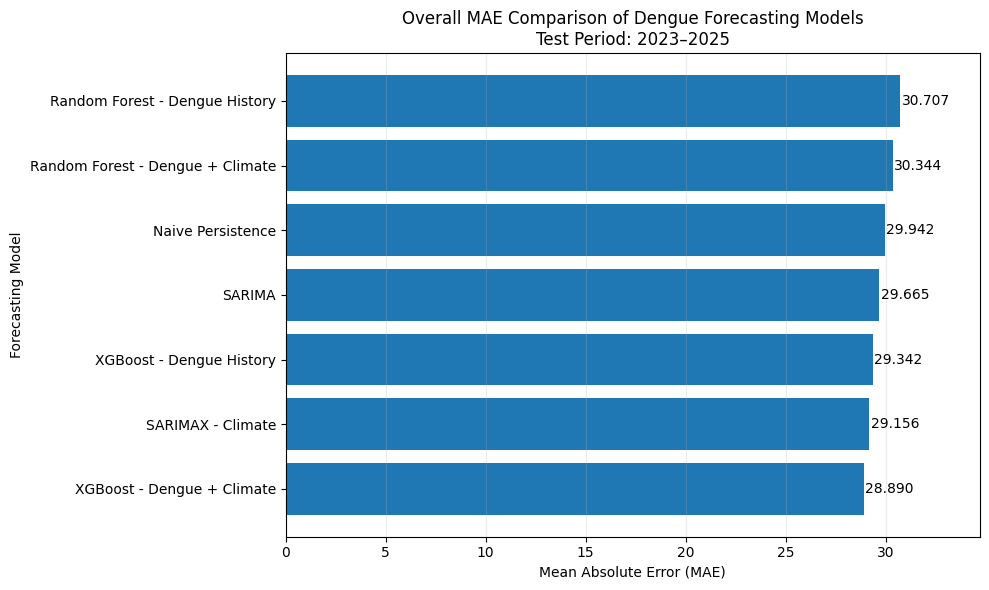

Saved: /content/drive/MyDrive/Capstone_Dengue_Project/outputs/figures/09_final_model_mae_comparison.png
File exists: True


In [13]:
# ============================================================
# 5.2 FINAL MODEL MAE COMPARISON FIGURE
# ============================================================

import matplotlib.pyplot as plt
import os

# Sort from lowest MAE to highest MAE
plot_df = final_comparison.sort_values(
    "MAE",
    ascending=True
).copy()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_df["Model"],
    plot_df["MAE"]
)

plt.xlabel("Mean Absolute Error (MAE)")
plt.ylabel("Forecasting Model")
plt.title(
    "Overall MAE Comparison of Dengue Forecasting Models\n"
    "Test Period: 2023–2025"
)

# Display MAE value beside each bar
for bar, value in zip(bars, plot_df["MAE"]):
    plt.text(
        value + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.xlim(
    0,
    plot_df["MAE"].max() + 4
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

FINAL_FIGURE_PATH = os.path.join(
    FIGURE_DIR,
    "09_final_model_mae_comparison.png"
)

plt.savefig(
    FINAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", FINAL_FIGURE_PATH)
print("File exists:", os.path.exists(FINAL_FIGURE_PATH))

## 6. Forecasting Application Development

Following model evaluation, the trained forecasting model is prepared for integration into an interactive application. The application will allow users to provide the required dengue and climate information and obtain a next-week dengue case forecast for a selected district.

Before application development, the saved model, preprocessing pipeline, and feature definitions are inspected to ensure that application inputs exactly match the model's training configuration.

In [14]:
# ============================================================
# 6.1 INSPECT SAVED DEPLOYMENT OBJECTS
# ============================================================

import os
import joblib

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "xgb_climate_model.pkl"
)

PREPROCESSOR_PATH = os.path.join(
    MODEL_DIR,
    "climate_preprocessor.pkl"
)

FEATURES_PATH = os.path.join(
    MODEL_DIR,
    "model_b_features.pkl"
)

# Load saved objects
saved_xgb_model = joblib.load(MODEL_PATH)
saved_preprocessor = joblib.load(PREPROCESSOR_PATH)
saved_features = joblib.load(FEATURES_PATH)

print("=== SAVED MODEL ===")
print("Type:", type(saved_xgb_model))

print("\n=== SAVED PREPROCESSOR ===")
print("Type:", type(saved_preprocessor))

print("\n=== SAVED FEATURE DEFINITION ===")
print("Type:", type(saved_features))
print(saved_features)

print("\n=== MODEL INFORMATION ===")

if hasattr(saved_xgb_model, "n_features_in_"):
    print(
        "Model expected input features:",
        saved_xgb_model.n_features_in_
    )

if hasattr(saved_preprocessor, "feature_names_in_"):
    print("\nPreprocessor input features:")
    print(
        list(saved_preprocessor.feature_names_in_)
    )

=== SAVED MODEL ===
Type: <class 'xgboost.sklearn.XGBRegressor'>

=== SAVED PREPROCESSOR ===
Type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>

=== SAVED FEATURE DEFINITION ===
Type: <class 'list'>
['district', 'cases', 'cases_lag_1', 'cases_lag_2', 'cases_lag_4', 'week_sin', 'week_cos', 'rainfall_total', 'temperature_mean', 'humidity_mean', 'rainfall_total_lag_1', 'rainfall_total_lag_2', 'rainfall_total_lag_4', 'rainfall_total_lag_8', 'temperature_mean_lag_1', 'temperature_mean_lag_2', 'temperature_mean_lag_4', 'temperature_mean_lag_8', 'humidity_mean_lag_1', 'humidity_mean_lag_2', 'humidity_mean_lag_4', 'humidity_mean_lag_8']

=== MODEL INFORMATION ===
Model expected input features: 26

Preprocessor input features:
['district', 'cases', 'cases_lag_1', 'cases_lag_2', 'cases_lag_4', 'week_sin', 'week_cos', 'rainfall_total', 'temperature_mean', 'humidity_mean', 'rainfall_total_lag_1', 'rainfall_total_lag_2', 'rainfall_total_lag_4', 'rainfall_total_lag_8', 'temperatur

### 6.2 Deployment Pipeline Verification

Before developing the user interface, the saved preprocessing pipeline and trained XGBoost model are tested using an existing observation from the processed dataset.

This verifies that the serialized model components can be loaded successfully and that the complete preprocessing-to-prediction workflow operates correctly outside the original training procedure.

In [15]:
# ============================================================
# 6.2 TEST SAVED XGBOOST DEPLOYMENT PIPELINE
# ============================================================

# Select the latest available observation from the
# processed forecasting dataset
sample_row = (
    model_df
    .sort_values("start.date")
    .iloc[-1]
)

# Construct model input using EXACTLY the features
# expected by the saved preprocessor
sample_input = pd.DataFrame(
    [sample_row[saved_features].to_dict()]
)

print("==============================================")
print("SAMPLE FORECAST INFORMATION")
print("==============================================")

print("District:", sample_row["district"])
print("Current week:", sample_row["start.date"])
print("Current dengue cases:", sample_row["cases"])
print("Actual next-week cases:", sample_row["cases_next_week"])

print("\nNumber of raw input features:")
print(sample_input.shape[1])

# ------------------------------------------------------------
# Apply saved preprocessing
# ------------------------------------------------------------

sample_processed = saved_preprocessor.transform(
    sample_input
)

print("\nProcessed feature shape:")
print(sample_processed.shape)

# ------------------------------------------------------------
# Generate prediction
# ------------------------------------------------------------

sample_prediction = saved_xgb_model.predict(
    sample_processed
)[0]

# Dengue counts cannot be negative
sample_prediction = max(
    0.0,
    float(sample_prediction)
)

print("\n==============================================")
print("MODEL OUTPUT")
print("==============================================")

print(
    f"Predicted next-week dengue cases: "
    f"{sample_prediction:.2f}"
)

print(
    f"Actual next-week dengue cases: "
    f"{sample_row['cases_next_week']:.0f}"
)

absolute_error = abs(
    sample_prediction -
    sample_row["cases_next_week"]
)

print(
    f"Absolute error for this example: "
    f"{absolute_error:.2f}"
)

SAMPLE FORECAST INFORMATION
District: Kandy
Current week: 2025-12-13 00:00:00
Current dengue cases: 85
Actual next-week cases: 86.0

Number of raw input features:
22

Processed feature shape:
(1, 26)

MODEL OUTPUT
Predicted next-week dengue cases: 77.44
Actual next-week dengue cases: 86
Absolute error for this example: 8.56


## 7. Interactive Forecasting Application

An interactive forecasting application is developed to demonstrate the practical use of the trained dengue forecasting model.

The application uses the saved XGBoost climate-enhanced model and its associated preprocessing pipeline to generate next-week dengue case forecasts for the selected districts.

In [16]:
# ============================================================
# 7.1 CREATE APPLICATION DIRECTORY
# ============================================================

APP_DIR = os.path.join(
    PROJECT_DIR,
    "app"
)

os.makedirs(
    APP_DIR,
    exist_ok=True
)

print("Application directory:")
print(APP_DIR)

print("\nApplication directory exists:")
print(os.path.exists(APP_DIR))

print("\nRequired deployment files:")

required_files = [
    "xgb_climate_model.pkl",
    "climate_preprocessor.pkl",
    "model_b_features.pkl"
]

for filename in required_files:

    path = os.path.join(
        MODEL_DIR,
        filename
    )

    print(
        f"{filename}:",
        os.path.exists(path)
    )

Application directory:
/content/drive/MyDrive/Capstone_Dengue_Project/app

Application directory exists:
True

Required deployment files:
xgb_climate_model.pkl: True
climate_preprocessor.pkl: True
model_b_features.pkl: True


### 7.2 Streamlit Application Implementation

The forecasting interface is implemented using Streamlit. The application collects the dengue surveillance and climate information required by the trained model, automatically calculates seasonal features, applies the saved preprocessing pipeline, and generates a next-week dengue case forecast.

In [17]:
# ============================================================
# 7.2 CREATE STREAMLIT APPLICATION
# ============================================================

app_code = r'''
import os
import math
import joblib
import pandas as pd
import streamlit as st


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Sri Lanka Dengue Forecasting",
    page_icon="🦟",
    layout="wide"
)


# ============================================================
# PATHS
# ============================================================

APP_DIR = os.path.dirname(os.path.abspath(__file__))

PROJECT_DIR = os.path.dirname(APP_DIR)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models"
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "xgb_climate_model.pkl"
)

PREPROCESSOR_PATH = os.path.join(
    MODEL_DIR,
    "climate_preprocessor.pkl"
)

FEATURES_PATH = os.path.join(
    MODEL_DIR,
    "model_b_features.pkl"
)


# ============================================================
# LOAD MODEL COMPONENTS
# ============================================================

@st.cache_resource
def load_model_components():

    model = joblib.load(MODEL_PATH)

    preprocessor = joblib.load(
        PREPROCESSOR_PATH
    )

    feature_list = joblib.load(
        FEATURES_PATH
    )

    return model, preprocessor, feature_list


try:

    model, preprocessor, feature_list = (
        load_model_components()
    )

except Exception as e:

    st.error(
        "Unable to load the forecasting model."
    )

    st.exception(e)

    st.stop()


# ============================================================
# HEADER
# ============================================================

st.title(
    "🦟 Weekly Dengue Forecasting in Sri Lanka"
)

st.write(
    """
    This application estimates dengue cases for the
    following week using historical dengue surveillance
    information, seasonal patterns, and climate variables.
    """
)

st.info(
    "The forecasting model was developed for Colombo, "
    "Gampaha, Jaffna, Kalutara and Kandy districts."
)


# ============================================================
# FORECAST SETTINGS
# ============================================================

st.header("1. Forecast Settings")

col1, col2 = st.columns(2)

with col1:

    district = st.selectbox(
        "District",
        [
            "Colombo",
            "Gampaha",
            "Jaffna",
            "Kalutara",
            "Kandy"
        ]
    )

with col2:

    week = st.number_input(
        "Current epidemiological week",
        min_value=1,
        max_value=53,
        value=1,
        step=1
    )


# ============================================================
# DENGUE HISTORY
# ============================================================

st.header("2. Dengue Case History")

st.caption(
    "Enter the number of reported dengue cases for "
    "the current and previous required weeks."
)

c1, c2, c3, c4 = st.columns(4)

with c1:

    cases = st.number_input(
        "Current week",
        min_value=0,
        value=0,
        step=1
    )

with c2:

    cases_lag_1 = st.number_input(
        "1 week ago",
        min_value=0,
        value=0,
        step=1
    )

with c3:

    cases_lag_2 = st.number_input(
        "2 weeks ago",
        min_value=0,
        value=0,
        step=1
    )

with c4:

    cases_lag_4 = st.number_input(
        "4 weeks ago",
        min_value=0,
        value=0,
        step=1
    )


# ============================================================
# CLIMATE INPUT FUNCTION
# ============================================================

def climate_inputs(
    title,
    prefix
):

    st.subheader(title)

    a, b, c, d, e = st.columns(5)

    with a:

        current = st.number_input(
            "Current week",
            value=0.0,
            key=f"{prefix}_current"
        )

    with b:

        lag1 = st.number_input(
            "1 week ago",
            value=0.0,
            key=f"{prefix}_lag1"
        )

    with c:

        lag2 = st.number_input(
            "2 weeks ago",
            value=0.0,
            key=f"{prefix}_lag2"
        )

    with d:

        lag4 = st.number_input(
            "4 weeks ago",
            value=0.0,
            key=f"{prefix}_lag4"
        )

    with e:

        lag8 = st.number_input(
            "8 weeks ago",
            value=0.0,
            key=f"{prefix}_lag8"
        )

    return (
        current,
        lag1,
        lag2,
        lag4,
        lag8
    )


# ============================================================
# CLIMATE HISTORY
# ============================================================

st.header("3. Climate History")

st.caption(
    "Provide weekly climate observations corresponding "
    "to the required historical periods."
)

rain = climate_inputs(
    "🌧️ Rainfall",
    "rain"
)

temperature = climate_inputs(
    "🌡️ Mean Temperature",
    "temp"
)

humidity = climate_inputs(
    "💧 Relative Humidity",
    "humidity"
)


# ============================================================
# PREDICTION
# ============================================================

st.divider()

if st.button(
    "🔮 Predict Next Week",
    type="primary",
    use_container_width=True
):

    # Seasonal encoding used during model training
    week_sin = math.sin(
        2 * math.pi * week / 52
    )

    week_cos = math.cos(
        2 * math.pi * week / 52
    )

    input_data = {
        "district": district,

        "cases": cases,
        "cases_lag_1": cases_lag_1,
        "cases_lag_2": cases_lag_2,
        "cases_lag_4": cases_lag_4,

        "week_sin": week_sin,
        "week_cos": week_cos,

        "rainfall_total": rain[0],
        "temperature_mean": temperature[0],
        "humidity_mean": humidity[0],

        "rainfall_total_lag_1": rain[1],
        "rainfall_total_lag_2": rain[2],
        "rainfall_total_lag_4": rain[3],
        "rainfall_total_lag_8": rain[4],

        "temperature_mean_lag_1": temperature[1],
        "temperature_mean_lag_2": temperature[2],
        "temperature_mean_lag_4": temperature[3],
        "temperature_mean_lag_8": temperature[4],

        "humidity_mean_lag_1": humidity[1],
        "humidity_mean_lag_2": humidity[2],
        "humidity_mean_lag_4": humidity[3],
        "humidity_mean_lag_8": humidity[4]
    }

    # Ensure exact training feature order
    input_df = pd.DataFrame(
        [input_data]
    )[feature_list]

    try:

        processed_input = (
            preprocessor.transform(
                input_df
            )
        )

        prediction = model.predict(
            processed_input
        )[0]

        prediction = max(
            0.0,
            float(prediction)
        )

        rounded_prediction = int(
            round(prediction)
        )

        st.success(
            "Forecast generated successfully."
        )

        st.metric(
            label=(
                f"Predicted dengue cases for "
                f"{district} next week"
            ),
            value=f"{rounded_prediction} cases"
        )

        st.caption(
            f"Raw model estimate: "
            f"{prediction:.2f} cases"
        )

    except Exception as e:

        st.error(
            "An error occurred while generating "
            "the forecast."
        )

        st.exception(e)


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Capstone Project II – Weekly Dengue Forecasting "
    "in Sri Lanka"
)
'''

APP_FILE = os.path.join(
    APP_DIR,
    "app.py"
)

with open(
    APP_FILE,
    "w",
    encoding="utf-8"
) as f:
    f.write(app_code)

print("Application file created:")
print(APP_FILE)

print(
    "\nFile exists:",
    os.path.exists(APP_FILE)
)

print(
    "File size:",
    os.path.getsize(APP_FILE),
    "bytes"
)

Application file created:
/content/drive/MyDrive/Capstone_Dengue_Project/app/app.py

File exists: True
File size: 7568 bytes


In [18]:
# ============================================================
# 7.3 CREATE APPLICATION REQUIREMENTS FILE
# ============================================================

requirements = """streamlit
pandas
numpy
scikit-learn
xgboost
joblib
"""

REQUIREMENTS_FILE = os.path.join(
    APP_DIR,
    "requirements.txt"
)

with open(
    REQUIREMENTS_FILE,
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements)

print("Requirements file created:")
print(REQUIREMENTS_FILE)

print("\nFile exists:")
print(os.path.exists(REQUIREMENTS_FILE))

print("\nContents:")
with open(REQUIREMENTS_FILE, "r") as f:
    print(f.read())


Requirements file created:
/content/drive/MyDrive/Capstone_Dengue_Project/app/requirements.txt

File exists:
True

Contents:
streamlit
pandas
numpy
scikit-learn
xgboost
joblib



In [19]:
import sklearn
import scipy
import numpy
import joblib
import xgboost

print("scikit-learn:", sklearn.__version__)
print("scipy:", scipy.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)
print("xgboost:", xgboost.__version__)


scikit-learn: 1.6.1
scipy: 1.16.3
numpy: 2.1.3
joblib: 1.6.0
xgboost: 3.4.1
